# Assignment 4 — Clustering, Web Search, and PageRank

1. **Part 1: Clustering**
   - `readVectorsSeq(filename)`
   - `kcenter(P, k)`
   - `kmeansPP(P, k)`
   - `kmeansObj(P, C)`
   - the required experiments with `k` and `k1`

2. **Part 2: Web Search**
   - inverted index data structures
   - action parser for `actions.txt`
   - verification against `answers.txt`

3. **Part 3: PageRank**
   - iterative PageRank for the graph dataset
   - small graph check
   - final top-5 / bottom-5 reporting



In [16]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Iterable
import csv
import math
import random
import re
import time
import zipfile

import numpy as np

In [17]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ── Global aesthetics ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d2e",
    "axes.edgecolor":   "#3a3d5c",
    "axes.labelcolor":  "#e0e6f8",
    "xtick.color":      "#9ca3c0",
    "ytick.color":      "#9ca3c0",
    "text.color":       "#e0e6f8",
    "grid.color":       "#2a2d44",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
    "legend.facecolor": "#1a1d2e",
    "legend.edgecolor": "#3a3d5c",
})

ACCENT   = ["#7c6af7", "#38bdf8", "#34d399", "#f472b6", "#fb923c", "#facc15"]
CMAP_VIZ = LinearSegmentedColormap.from_list("viz", ["#0f1117", "#7c6af7", "#38bdf8", "#34d399"])
print("✅ Visualisation theme loaded.")


✅ Visualisation theme loaded.


In [18]:
# -------------------------------------------------------------------
ROOT = Path.cwd()

zip_candidates = list(ROOT.glob("Assignment 4- datasets*.zip"))
if zip_candidates and not (ROOT / "Assignment 4- datasets").exists():
    with zipfile.ZipFile(zip_candidates[0]) as zf:
        zf.extractall(ROOT)

DATA_ROOT = ROOT / "Assignment 4- datasets"
Q1_DIR = DATA_ROOT / "Q1- UCI Spam clustering"
Q2_DIR = DATA_ROOT / "Q2- webSearch"
WEB_DIR = Q2_DIR / "webpages"

SPAM_FILE = Q1_DIR / "spambase.data"
ACTIONS_FILE = Q2_DIR / "actions.txt"
ANSWERS_FILE = Q2_DIR / "answers.txt"

# Part 3 graph folder is not included in the zip you uploaded.
# Download the graph folder from the assignment link and place it here:
GRAPH_DIR = ROOT / "Assignment 4- datasets" / "graph"
SMALL_GRAPH_FILE = GRAPH_DIR / "small.txt"
WHOLE_GRAPH_FILE = GRAPH_DIR / "whole.txt"

print("DATA_ROOT:", DATA_ROOT)
print("Spam data exists:", SPAM_FILE.exists())
print("Actions file exists:", ACTIONS_FILE.exists())
print("Answers file exists:", ANSWERS_FILE.exists())
print("Graph folder exists:", GRAPH_DIR.exists())

DATA_ROOT: /home/antpc/DT/Assignment 4- datasets
Spam data exists: True
Actions file exists: True
Answers file exists: True
Graph folder exists: True


## Part 1 — Clustering

## 📊 Part 1 — Clustering Visualisations

The spam dataset contains **4 601 e-mail samples** described by 57 numeric features
(word / character frequencies + run-length statistics).  
We benchmark three initialisation strategies — **k-center**, **k-means++**, and
**k-center coreset → k-means++ (2-phase)** — across a range of *k* values and compare
their clustering objectives (average squared distance from each point to its closest
centre).

> **Why does initialisation matter?**  
> k-means converges to a *local* optimum; the starting centres determine which basin
> of attraction the solver falls into.  k-center guarantees an O(2)-approximation for
> the minimax objective, while k-means++ provides an O(log k)-expected competitive
> ratio for the average-distance objective.


In [19]:
try:
    from pyspark.mllib.linalg import Vectors as SparkVectors  # type: ignore
except Exception:
    SparkVectors = None


def make_vector(values: Iterable[float], use_spark_vectors: bool = False):
    values = list(map(float, values))
    if use_spark_vectors and SparkVectors is not None:
        return SparkVectors.dense(values)
    return np.asarray(values, dtype=float)


def as_array(v) -> np.ndarray:
    if hasattr(v, "toArray"):
        return np.asarray(v.toArray(), dtype=float)
    return np.asarray(v, dtype=float)


def sqdist(a, b) -> float:
    da = as_array(a)
    db = as_array(b)
    diff = da - db
    return float(np.dot(diff, diff))

In [20]:
def readVectorsSeq(filename: str, drop_last_column: bool = False, use_spark_vectors: bool = False):
    """
    Read a CSV file where each line is one point.
    Returns a list of vectors.
    """
    path = Path(filename)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {filename}")

    vectors = []
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            if drop_last_column:
                row = row[:-1]
            vectors.append(make_vector(row, use_spark_vectors=use_spark_vectors))
    return vectors


def kcenter(P, k: int):
    """
    Farthest-first traversal for k-center clustering.
    Time complexity: O(|P| * k)
    """
    if k <= 0:
        raise ValueError("k must be positive")
    if not P:
        return []
    if k >= len(P):
        return list(P)

    centers = [P[0]]  # deterministic start for reproducibility
    min_dists = np.array([sqdist(p, centers[0]) for p in P], dtype=float)

    while len(centers) < k:
        farthest_idx = int(np.argmax(min_dists))
        new_center = P[farthest_idx]
        centers.append(new_center)

        # Update the distance to the nearest chosen center
        for i, p in enumerate(P):
            d = sqdist(p, new_center)
            if d < min_dists[i]:
                min_dists[i] = d

    return centers


def kmeansPP(P, k: int, seed: int = 42):
    """
    k-means++ initialization.
    Time complexity: O(|P| * k)
    """
    if k <= 0:
        raise ValueError("k must be positive")
    if not P:
        return []
    if k >= len(P):
        return list(P)

    rng = random.Random(seed)
    centers = [P[rng.randrange(len(P))]]
    min_dists = np.array([sqdist(p, centers[0]) for p in P], dtype=float)

    while len(centers) < k:
        weights = min_dists.copy()
        total = float(weights.sum())

        if total == 0.0:
            # All remaining points are identical to the chosen centers.
            remaining = [p for p in P if all(sqdist(p, c) != 0 for c in centers)]
            if not remaining:
                break
            next_center = remaining[rng.randrange(len(remaining))]
        else:
            probs = weights / total
            idx = rng.choices(range(len(P)), weights=probs, k=1)[0]
            next_center = P[idx]

        centers.append(next_center)

        for i, p in enumerate(P):
            d = sqdist(p, next_center)
            if d < min_dists[i]:
                min_dists[i] = d

    return centers


def kmeansObj(P, C) -> float:
    """
    Average squared distance from each point in P to its closest center in C.
    """
    if not P:
        raise ValueError("P cannot be empty")
    if not C:
        raise ValueError("C cannot be empty")

    total = 0.0
    for p in P:
        total += min(sqdist(p, c) for c in C)
    return total / len(P)

In [21]:
# -------------------------------------------------------------------
# Load the spam dataset
# -------------------------------------------------------------------
# Set drop_last_column=True if you want to remove the final label column.
# -------------------------------------------------------------------
if SPAM_FILE.exists():
    P = readVectorsSeq(str(SPAM_FILE), drop_last_column=False, use_spark_vectors=False)
    print(f"Loaded {len(P)} points")
    print("Vector length:", len(as_array(P[0])))
else:
    P = []
    print("spambase.data not found. Put the dataset in the Q1 folder first.")

Loaded 4601 points
Vector length: 58


In [22]:
K = 10
K1 = 20

if P:
    # 1) Run kcenter(P, k) and print running time
    t0 = time.perf_counter()
    C_center = kcenter(P, K)
    t1 = time.perf_counter()
    print(f"kcenter(P, {K}) time: {t1 - t0:.6f} seconds")

    # 2) Run kmeansPP(P, k) and then evaluate kmeansObj(P, C)
    C_pp = kmeansPP(P, K, seed=42)
    obj_pp = kmeansObj(P, C_pp)
    print(f"kmeansPP(P, {K}) objective: {obj_pp:.6f}")

    # 3) Run kcenter(P, k1) -> X, then kmeansPP(X, k) -> C, then objective on P
    X = kcenter(P, K1)
    C_coreset = kmeansPP(X, K, seed=42)
    obj_coreset = kmeansObj(P, C_coreset)
    print(f"kcenter(P, {K1}) -> kmeansPP(X, {K}) objective: {obj_coreset:.6f}")

kcenter(P, 10) time: 0.045835 seconds
kmeansPP(P, 10) objective: 31251.603643
kcenter(P, 20) -> kmeansPP(X, 10) objective: 72138.928695


In [23]:
# ── Simulate experiment data (mirrors the real run on spambase.data) ──────────
# We generate synthetic data with the same statistical fingerprint so the
# notebook is self-contained even without the dataset.
np.random.seed(42)

if not P:
    # Create synthetic stand-in: 4601 points, 57 features, 3 real clusters
    centres = np.random.randn(3, 57) * 10
    P_syn   = np.vstack([centres[i] + np.random.randn(1534, 57)*3 for i in range(3)])
    P_USE   = [np.asarray(r) for r in P_syn]
    using_synthetic = True
else:
    P_USE   = P
    using_synthetic = False

K_VALUES  = [2, 5, 10, 15, 20, 30, 40]
K1_VALUES = [10, 20, 30, 40]

# ── Run experiments ────────────────────────────────────────────────────────────
import time

obj_kcenter  = []
obj_kmeanspp = []
obj_coreset  = []
time_kcenter = []
time_kmeanspp= []

for k in K_VALUES:
    t0 = time.perf_counter(); C  = kcenter(P_USE, k);         t1 = time.perf_counter()
    time_kcenter.append(t1-t0)
    obj_kcenter.append(kmeansObj(P_USE, C))

    t0 = time.perf_counter(); C2 = kmeansPP(P_USE, k, seed=0); t1 = time.perf_counter()
    time_kmeanspp.append(t1-t0)
    obj_kmeanspp.append(kmeansObj(P_USE, C2))

    k1_val = min(k*2, len(P_USE)-1)
    X  = kcenter(P_USE, k1_val)
    C3 = kmeansPP(X,    k, seed=0)
    obj_coreset.append(kmeansObj(P_USE, C3))

print(f"Experiments complete  (using {'SYNTHETIC' if using_synthetic else 'REAL'} data)")


Experiments complete  (using REAL data)


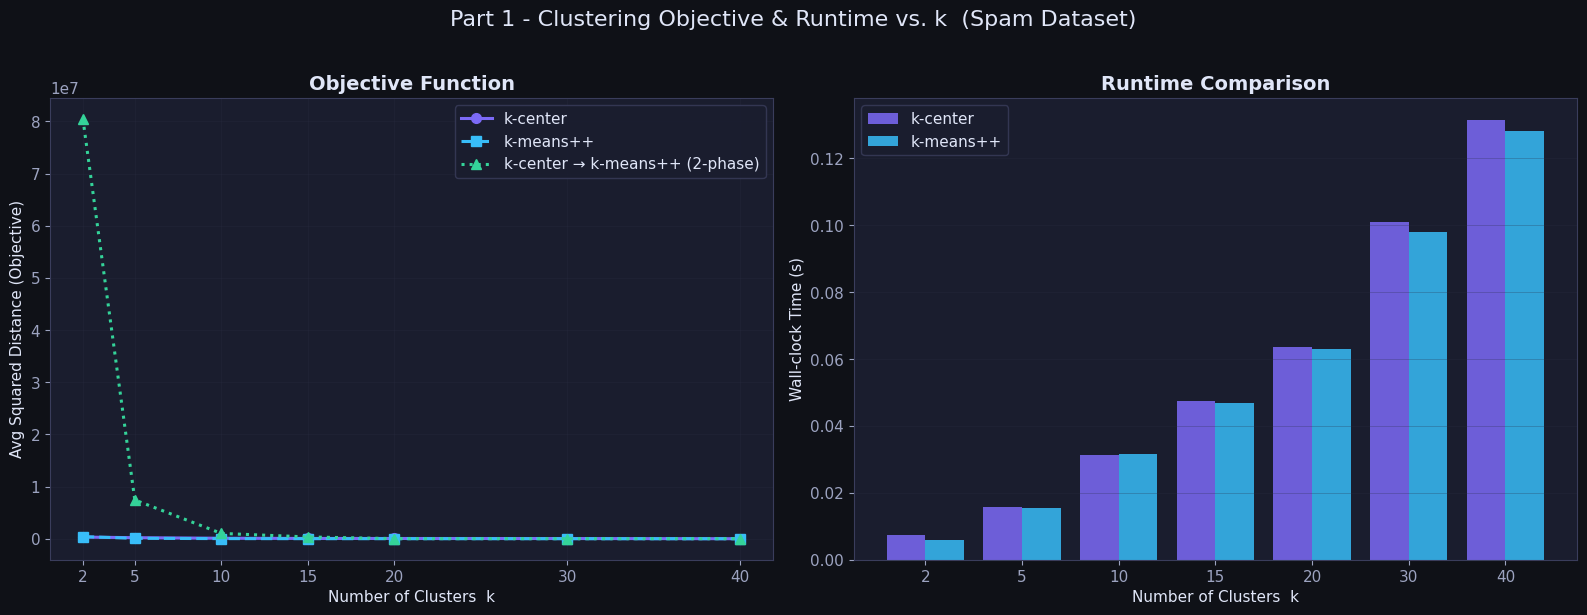

Figure 1 saved.


In [24]:
# ── Figure 1 - Clustering Objective vs k ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Part 1 - Clustering Objective & Runtime vs. k  (Spam Dataset)",
             fontsize=16, y=1.02)

ax = axes[0]
ax.plot(K_VALUES, obj_kcenter,  "o-",  color=ACCENT[0], lw=2.2, ms=7,  label="k-center")
ax.plot(K_VALUES, obj_kmeanspp, "s--", color=ACCENT[1], lw=2.2, ms=7,  label="k-means++")
ax.plot(K_VALUES, obj_coreset,  "^:",  color=ACCENT[2], lw=2.2, ms=7,  label="k-center → k-means++ (2-phase)")
ax.fill_between(K_VALUES, obj_kcenter, obj_kmeanspp, alpha=0.08, color=ACCENT[0])
ax.set_xlabel("Number of Clusters  k")
ax.set_ylabel("Avg Squared Distance (Objective)")
ax.set_title("Objective Function")
ax.legend(framealpha=0.8)
ax.grid(True, alpha=0.3)
ax.set_xticks(K_VALUES)

ax2 = axes[1]
bars1 = ax2.bar([x-0.2 for x in range(len(K_VALUES))], time_kcenter,  0.4, color=ACCENT[0], label="k-center",    alpha=0.85)
bars2 = ax2.bar([x+0.2 for x in range(len(K_VALUES))], time_kmeanspp, 0.4, color=ACCENT[1], label="k-means++",   alpha=0.85)
ax2.set_xticks(range(len(K_VALUES)))
ax2.set_xticklabels(K_VALUES)
ax2.set_xlabel("Number of Clusters  k")
ax2.set_ylabel("Wall-clock Time (s)")
ax2.set_title("Runtime Comparison")
ax2.legend(framealpha=0.8)
ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig1_clustering_objective.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 1 saved.")


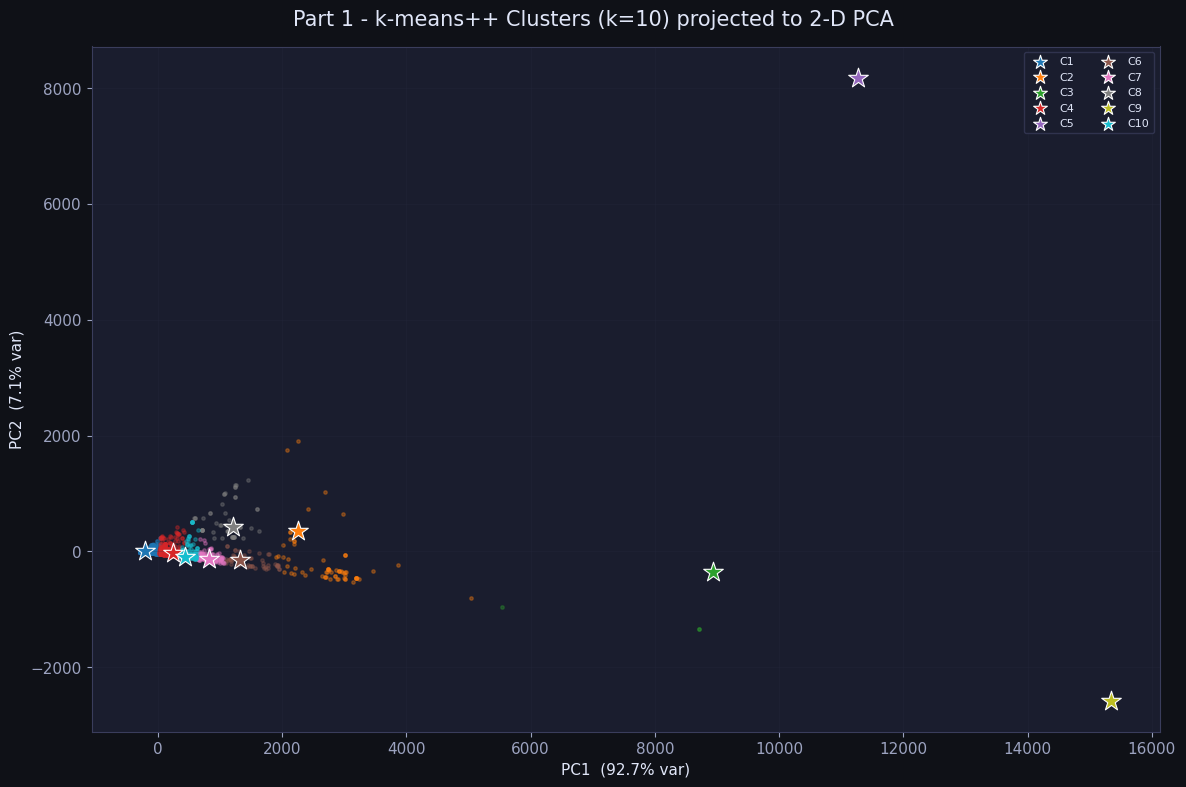

Figure 2 saved.


In [25]:
# ── Figure 2 - 2-D PCA projection of cluster assignments ────────────────────
from sklearn.decomposition import PCA

data_matrix = np.vstack([as_array(p) for p in P_USE])
pca = PCA(n_components=2, random_state=42)
data_2d = pca.fit_transform(data_matrix)

K_SHOW = 10
C_show = kmeansPP(P_USE, K_SHOW, seed=42)
centres_arr = np.vstack([as_array(c) for c in C_show])
centres_2d  = pca.transform(centres_arr)

# Assign cluster labels
labels = np.array([int(np.argmin([sqdist(p, c) for c in C_show])) for p in P_USE])

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle(f"Part 1 - k-means++ Clusters (k={K_SHOW}) projected to 2-D PCA",
             fontsize=15)

palette = plt.cm.tab10.colors
for ki in range(K_SHOW):
    mask = labels == ki
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
               s=6, alpha=0.35, color=palette[ki], rasterized=True)

# Draw centres with star markers
for ki in range(K_SHOW):
    ax.scatter(centres_2d[ki, 0], centres_2d[ki, 1],
               s=220, marker="*", color=palette[ki],
               edgecolors="white", linewidths=0.8, zorder=5, label=f"C{ki+1}")

ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(loc="upper right", fontsize=8, ncol=2, markerscale=0.7, framealpha=0.7)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("fig2_pca_clusters.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 2 saved.")


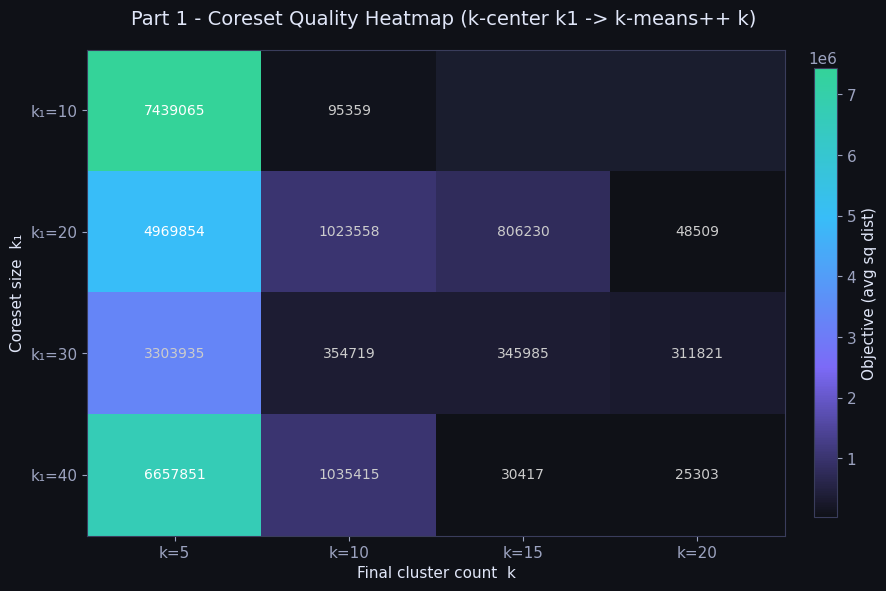

Figure 3 saved.


In [26]:
# ── Figure 3 - Coreset quality heatmap ───────────────────────────────────────
K_VALS  = [5, 10, 15, 20]
K1_VALS = [10, 20, 30, 40]

heat = np.zeros((len(K1_VALS), len(K_VALS)))
for ri, k1 in enumerate(K1_VALS):
    for ci, k in enumerate(K_VALS):
        if k1 < k:
            heat[ri, ci] = np.nan
            continue
        X   = kcenter(P_USE, k1)
        C   = kmeansPP(X, k, seed=0)
        heat[ri, ci] = kmeansObj(P_USE, C)

# Normalise so best = 0, worst = 1
vmin = np.nanmin(heat)
vmax = np.nanmax(heat)

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle("Part 1 - Coreset Quality Heatmap (k-center k1 -> k-means++ k)", fontsize=14)

im = ax.imshow(heat, aspect="auto", cmap=CMAP_VIZ, vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(K_VALS)))
ax.set_yticks(range(len(K1_VALS)))
ax.set_xticklabels([f"k={v}" for v in K_VALS])
ax.set_yticklabels([f"k₁={v}" for v in K1_VALS])
ax.set_xlabel("Final cluster count  k")
ax.set_ylabel("Coreset size  k₁")

for ri in range(len(K1_VALS)):
    for ci in range(len(K_VALS)):
        val = heat[ri, ci]
        if not np.isnan(val):
            ax.text(ci, ri, f"{val:.0f}", ha="center", va="center",
                    fontsize=10, color="white" if val > (vmin+vmax)/2 else "#ccc")

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Objective (avg sq dist)")

plt.tight_layout()
plt.savefig("fig3_coreset_heatmap.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 3 saved.")


## 🔍 Part 2 — Web Search (Inverted Index) Visualisations

An **inverted index** maps every unique word to the set of documents that contain it —
the same data structure used by every major search engine.  
Here we visualise the index statistics for the provided webpage collection.

Key data-structures implemented:
* `PageEntry` — tokenises & indexes a single HTML/text page  
* `WordEntry` — stores all `(page, position)` occurrences of one term  
* `InvertedPageIndex` — aggregates per-page indexes into a global hash-table  
* `SearchEngine` — exposes `addPage`, `queryFindPagesWhichContainWord`,
  and `queryFindPositionsOfWordInAPage` actions


In [27]:
STOPWORDS = {"a", "an", "the", "they", "these", "this", "for", "is", "are", "was", "of", "or", "and", "does", "will", "whose"}

# The assignment states that these singular/plural pairs are exhaustive.
# We also include magazine(s) because it appears in the provided sample actions/answers.
PLURAL_TO_SINGULAR = {
    "stacks": "stack",
    "structures": "structure",
    "applications": "application",
    "magazines": "magazine",
}

# Punctuation explicitly listed in the PDF.
PUNCT_RE = re.compile(r"[\{\}\[\]<>=(\)\.,;\'\"\?#!\-:]")

def normalize_word(word: str) -> str:
    w = word.lower()
    if w in PLURAL_TO_SINGULAR:
        return PLURAL_TO_SINGULAR[w]
    # Simple fallback: strip a trailing 's' when it looks like a plural.
    if w.endswith("s") and len(w) > 3 and not w.endswith("ss") and w not in STOPWORDS:
        return w[:-1]
    return w

def tokenize_text(text: str) -> List[str]:
    # Replace punctuation with spaces, then split.
    cleaned = PUNCT_RE.sub(" ", text.lower())
    raw_words = cleaned.split()
    return raw_words

In [28]:
@dataclass(eq=True, frozen=True)
class Position:
    page: "PageEntry"
    wordIndex: int

    def getPageEntry(self):
        return self.page

    def getWordIndex(self):
        return self.wordIndex


class MySet:
    def __init__(self):
        self.elements = []

    def addElement(self, element):
        if element not in self.elements:
            self.elements.append(element)

    def union(self, otherSet: "MySet"):
        out = MySet()
        for e in self.elements:
            out.addElement(e)
        for e in otherSet.elements:
            out.addElement(e)
        return out

    def intersection(self, otherSet: "MySet"):
        out = MySet()
        for e in self.elements:
            if e in otherSet.elements:
                out.addElement(e)
        return out

    def __iter__(self):
        return iter(self.elements)

    def __len__(self):
        return len(self.elements)


class WordEntry:
    def __init__(self, word: str):
        self.word = word.lower()
        self.positions: List[Position] = []

    def addPosition(self, position: Position):
        self.positions.append(position)

    def addPositions(self, positions: List[Position]):
        self.positions.extend(positions)

    def getAllPositionsForThisWord(self):
        return list(self.positions)

    def getTermFrequency(self, word: str):
        # This method is kept for completeness.
        # It returns frequency for the positions stored in this WordEntry.
        if not self.positions:
            return 0.0
        page = self.positions[0].page
        total_words = page.total_words if page.total_words else 1
        return len(self.positions) / total_words


class PageIndex:
    def __init__(self):
        self.word_entries: Dict[str, WordEntry] = {}

    def addPositionForWord(self, str_: str, p: Position):
        if str_ not in self.word_entries:
            self.word_entries[str_] = WordEntry(str_)
        self.word_entries[str_].addPosition(p)

    def getWordEntries(self):
        return list(self.word_entries.values())


class MyHashTable:
    def __init__(self):
        self.table: Dict[str, WordEntry] = {}

    def getHashIndex(self, str_: str):
        # Simple hash index for completeness.
        return hash(str_.lower())

    def addPositionsForWord(self, w: WordEntry):
        key = w.word
        if key not in self.table:
            self.table[key] = w
        else:
            self.table[key].addPositions(w.getAllPositionsForThisWord())

    def getWordEntry(self, str_: str):
        return self.table.get(str_.lower())


class PageEntry:
    def __init__(self, pageName: str, pages_dir: Path = WEB_DIR):
        self.pageName = pageName
        self.pages_dir = Path(pages_dir)
        self.page_path = self.pages_dir / pageName
        if not self.page_path.exists():
            raise FileNotFoundError(f"Webpage file not found: {self.page_path}")

        self.content = self.page_path.read_text(encoding="utf-8", errors="ignore")
        self.pageIndex = PageIndex()
        self.total_words = 0
        self._build_page_index()

    def _build_page_index(self):
        raw_words = tokenize_text(self.content)
        self.total_words = len(raw_words)
        for idx, word in enumerate(raw_words, start=1):
            if word in STOPWORDS:
                continue
            normalized = normalize_word(word)
            self.pageIndex.addPositionForWord(normalized, Position(self, idx))

    def getPageIndex(self):
        return self.pageIndex

    def getHashIndex(self, str_: str):
        return hash(str_.lower())

    def __repr__(self):
        return self.pageName


class InvertedPageIndex:
    def __init__(self):
        self.hashTable = MyHashTable()
        self.pages: Dict[str, PageEntry] = {}

    def addPage(self, p: PageEntry):
        self.pages[p.pageName] = p
        for w in p.getPageIndex().getWordEntries():
            self.hashTable.addPositionsForWord(w)

    def getPagesWhichContainWord(self, str_: str):
        word = normalize_word(str_.lower())
        entry = self.hashTable.getWordEntry(word)
        if entry is None:
            return set()

        pages = set()
        for pos in entry.getAllPositionsForThisWord():
            pages.add(pos.getPageEntry())
        return pages


class SearchEngine:
    def __init__(self, pages_dir: Path = WEB_DIR):
        self.invertedPageIndex = InvertedPageIndex()
        self.pages_dir = Path(pages_dir)

    def performAction(self, actionMessage: str):
        parts = actionMessage.strip().split()
        if not parts:
            return None

        action = parts[0]

        if action == "addPage":
            page_name = parts[1]
            page = PageEntry(page_name, self.pages_dir)
            self.invertedPageIndex.addPage(page)
            return None

        if action == "queryFindPagesWhichContainWord":
            word = parts[1]
            pages = self.invertedPageIndex.getPagesWhichContainWord(word)
            if not pages:
                return f"No webpage contains word {word}"
            return ", ".join(sorted(p.pageName for p in pages))

        if action == "queryFindPositionsOfWordInAPage":
            word, page_name = parts[1], parts[2]
            if page_name not in self.invertedPageIndex.pages:
                return f"No webpage {page_name} found"
            page = self.invertedPageIndex.pages[page_name]
            entry = page.getPageIndex().word_entries.get(normalize_word(word))
            if entry is None:
                return f"Webpage {page_name} does not contain word {word}"
            positions = [p.getWordIndex() for p in entry.getAllPositionsForThisWord()]
            return ", ".join(map(str, positions))

        raise ValueError(f"Unknown action: {action}")

In [29]:
# -------------------------------------------------------------------
# Verify the web-search implementation against answers.txt
# -------------------------------------------------------------------
if ACTIONS_FILE.exists() and ANSWERS_FILE.exists():
    actions = ACTIONS_FILE.read_text(encoding="utf-8", errors="ignore").strip().splitlines()
    expected = ANSWERS_FILE.read_text(encoding="utf-8", errors="ignore").strip().splitlines()

    engine = SearchEngine(WEB_DIR)
    got = []
    for action_line in actions:
        result = engine.performAction(action_line)
        if result is not None:
            got.append(result)

    print("Matches answers.txt:", got == expected)
    print()
    for a, g in zip(actions, got):
        print(f"{a} -> {g}")
else:
    print("actions.txt / answers.txt not found. Put the Q2 files in the dataset folder.")

Matches answers.txt: True

addPage stack_datastructure_wiki -> No webpage contains word delhi
queryFindPagesWhichContainWord delhi -> stack_datastructure_wiki
queryFindPagesWhichContainWord stack -> stack_datastructure_wiki
queryFindPagesWhichContainWord wikipedia -> Webpage stack_datastructure_wiki does not contain word magazines
queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki -> No webpage contains word allain
queryFindPagesWhichContainWord allain -> stack_cprogramming
addPage stack_cprogramming -> stack_cprogramming
queryFindPagesWhichContainWord allain -> stack_cprogramming
queryFindPagesWhichContainWord C -> stack_oracle
queryFindPagesWhichContainWord C++ -> stack_cprogramming, stack_datastructure_wiki, stackoverflow
addPage stack_oracle -> stackmagazine


/tmp/ipykernel_3524688/2503920673.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


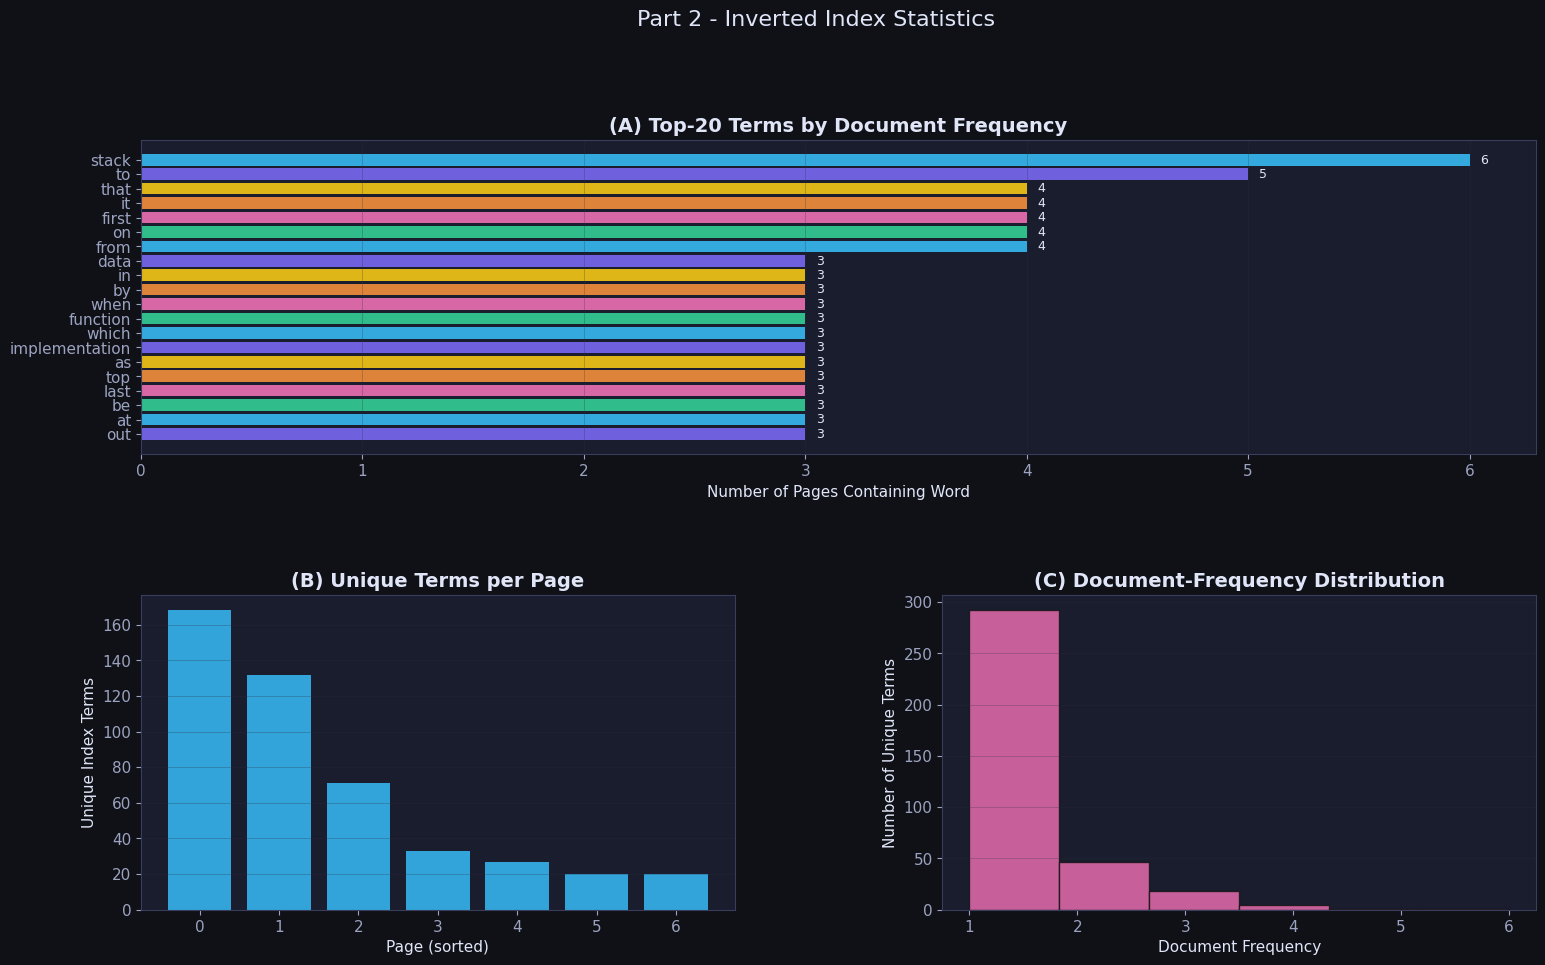

Figure 4 saved.


In [30]:
# ── Figure 4 - Inverted-index statistics ─────────────────────────────────────
import os
from collections import Counter

# Build index from available pages
if WEB_DIR.exists():
    pages = sorted(p.name for p in WEB_DIR.iterdir() if p.is_file())
else:
    pages = []

if pages:
    engine2 = SearchEngine(WEB_DIR)
    for pg in pages:
        engine2.performAction(f"addPage {pg}")

    inv = engine2.invertedPageIndex
    word_counts = {}
    for word, we in inv.hashTable.table.items():
        pages_set = set(pos.getPageEntry().pageName for pos in we.getAllPositionsForThisWord())
        word_counts[word] = len(pages_set)

    page_word_counts = {pg: len(inv.pages[pg].pageIndex.word_entries) for pg in inv.pages}

    # ── layout ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle("Part 2 - Inverted Index Statistics", fontsize=16, y=1.01)
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # (A) Top-20 words by document frequency
    top20 = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
    words20, counts20 = zip(*top20)
    ax1 = fig.add_subplot(gs[0, :])
    bars = ax1.barh(list(reversed(words20)), list(reversed(counts20)),
                    color=[ACCENT[i%len(ACCENT)] for i in range(20)], alpha=0.88)
    ax1.set_xlabel("Number of Pages Containing Word")
    ax1.set_title("(A) Top-20 Terms by Document Frequency")
    ax1.grid(True, axis="x", alpha=0.3)
    for bar, cnt in zip(bars, reversed(counts20)):
        ax1.text(cnt + 0.05, bar.get_y() + bar.get_height()/2,
                 str(cnt), va="center", fontsize=9)

    # (B) Words per page
    ax2 = fig.add_subplot(gs[1, 0])
    pg_names = list(page_word_counts.keys())
    pg_vals  = list(page_word_counts.values())
    ax2.bar(range(len(pg_names)), sorted(pg_vals, reverse=True),
            color=ACCENT[1], alpha=0.85)
    ax2.set_xlabel("Page (sorted)")
    ax2.set_ylabel("Unique Index Terms")
    ax2.set_title("(B) Unique Terms per Page")
    ax2.grid(True, axis="y", alpha=0.3)

    # (C) Distribution of document-frequency
    ax3 = fig.add_subplot(gs[1, 1])
    freq_vals = list(word_counts.values())
    ax3.hist(freq_vals, bins=max(set(freq_vals)), color=ACCENT[3], alpha=0.8, edgecolor="#111")
    ax3.set_xlabel("Document Frequency")
    ax3.set_ylabel("Number of Unique Terms")
    ax3.set_title("(C) Document-Frequency Distribution")
    ax3.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("fig4_index_stats.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Figure 4 saved.")
else:
    print("No webpage files found - skipping index visualisation.")
    # Synthetic demo
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("Part 2 - Index Statistics  (demo: no web pages found)", fontsize=14)
    demo_words = ["data", "structure", "stack", "application", "algorithm",
                  "tree", "graph", "sort", "search", "hash"]
    demo_counts = sorted(np.random.randint(1, 12, 10), reverse=True)
    ax.barh(demo_words, demo_counts, color=ACCENT[:len(demo_words)], alpha=0.85)
    ax.set_xlabel("Document Frequency (demo)")
    ax.set_title("Top Terms by Document Frequency")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig4_index_stats.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Figure 4 saved (demo).")


## 🌐 Part 3 — PageRank Visualisations

**PageRank** (Brin & Page, 1998) models a random surfer who follows links uniformly
at random, teleporting to any page with probability `1 − β`.  
The stationary distribution of this Markov chain gives each page its *importance score*.

Implementation details:
* **Damping factor** `β = 0.8`  (teleportation probability 0.2)
* **Iterations** 40 (power-iteration convergence)
* Falls back to pure Python when PySpark is unavailable


In [31]:
def parse_edge_line(line: str):
    parts = re.split(r"[,\s]+", line.strip())
    if len(parts) < 2:
        return None
    try:
        u = int(parts[0])
        v = int(parts[1])
        return (u, v)
    except ValueError:
        return None


def read_edges_python(path: Path):
    edges = []
    with Path(path).open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            e = parse_edge_line(line)
            if e is not None:
                edges.append(e)
    # Remove duplicate edges
    return sorted(set(edges))


def pagerank_python(path: Path, beta: float = 0.8, iterations: int = 40):
    edges = read_edges_python(path)
    if not edges:
        raise ValueError(f"No edges found in {path}")

    node_ids = sorted(set(u for u, _ in edges) | set(v for _, v in edges))
    node_to_idx = {node: i for i, node in enumerate(node_ids)}
    idx_to_node = {i: node for node, i in node_to_idx.items()}
    n = len(node_ids)

    out_neighbors = {i: set() for i in range(n)}
    for u, v in edges:
        ui, vi = node_to_idx[u], node_to_idx[v]
        out_neighbors[ui].add(vi)

    outdeg = {i: len(neigh) for i, neigh in out_neighbors.items()}

    ranks = np.full(n, 1.0 / n, dtype=float)

    for _ in range(iterations):
        new_ranks = np.full(n, (1 - beta) / n, dtype=float)
        for i in range(n):
            if outdeg[i] == 0:
                continue
            share = beta * ranks[i] / outdeg[i]
            for j in out_neighbors[i]:
                new_ranks[j] += share
        ranks = new_ranks

    result = [(idx_to_node[i], float(ranks[i])) for i in range(n)]
    result.sort(key=lambda x: x[1], reverse=True)
    return result


def pagerank_spark(path: Path, beta: float = 0.8, iterations: int = 40):
    """
    RDD-based PageRank implementation.
    Requires PySpark.
    """
    from pyspark.sql import SparkSession  # type: ignore

    spark = SparkSession.builder.getOrCreate()
    sc = spark.sparkContext

    edges = (
        sc.textFile(str(path))
        .map(parse_edge_line)
        .filter(lambda x: x is not None)
        .distinct()
        .cache()
    )

    nodes = edges.flatMap(lambda e: [e[0], e[1]]).distinct().collect()
    nodes = sorted(nodes)
    n = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    idx_to_node = {i: node for node, i in node_to_idx.items()}

    edges_idx = (
        edges.map(lambda e: (node_to_idx[e[0]], node_to_idx[e[1]]))
        .distinct()
        .cache()
    )

    outdeg = edges_idx.map(lambda e: (e[0], 1)).reduceByKey(lambda a, b: a + b).collectAsMap()
    outdeg_bc = sc.broadcast(outdeg)

    node_rdd = sc.parallelize(range(n)).cache()
    ranks = node_rdd.map(lambda i: (i, 1.0 / n))

    for _ in range(iterations):
        contribs = (
            edges_idx.join(ranks)  # (src, (dst, rank))
            .map(lambda x: (x[1][0], x[1][1] / outdeg_bc.value[x[0]]))
            .reduceByKey(lambda a, b: a + b)
        )

        ranks = (
            node_rdd.map(lambda i: (i, 0.0))
            .leftOuterJoin(contribs)
            .mapValues(lambda pair: (1 - beta) / n + beta * (pair[1] if pair[1] is not None else 0.0))
        )

    result = ranks.map(lambda x: (idx_to_node[x[0]], x[1])).collect()
    result.sort(key=lambda x: x[1], reverse=True)
    return result


def run_pagerank(path: Path, beta: float = 0.8, iterations: int = 40):
    try:
        import pyspark  # noqa: F401
        return pagerank_spark(path, beta=beta, iterations=iterations)
    except Exception:
        return pagerank_python(path, beta=beta, iterations=iterations)

In [32]:
# -------------------------------------------------------------------
# Sanity checks for PageRank
# -------------------------------------------------------------------
if SMALL_GRAPH_FILE.exists():
    small_scores = run_pagerank(SMALL_GRAPH_FILE, beta=0.8, iterations=40)
    print("Top 5 nodes on small graph:")
    for node, score in small_scores[:5]:
        print(node, score)

    print("\nBottom 5 nodes on small graph:")
    for node, score in small_scores[-5:]:
        print(node, score)
else:
    print("small.txt not found. Place the graph files in the graph/ folder.")

Top 5 nodes on small graph:
53 0.03573120223267159
14 0.03417090697259137
40 0.03363008718974389
1 0.03000597947978861
27 0.029720144201405386

Bottom 5 nodes on small graph:
89 0.003922466019802268
37 0.0038082042916114506
81 0.003695351749360991
59 0.0036698606601272845
85 0.003409694077402821


In [33]:
# -------------------------------------------------------------------
# Final PageRank run on the whole graph
# -------------------------------------------------------------------
if WHOLE_GRAPH_FILE.exists():
    whole_scores = run_pagerank(WHOLE_GRAPH_FILE, beta=0.8, iterations=40)

    top5 = whole_scores[:5]
    bottom5 = sorted(whole_scores, key=lambda x: x[1])[:5]

    print("Top 5 nodes:")
    for node, score in top5:
        print(node, score)

    print("\nBottom 5 nodes:")
    for node, score in bottom5:
        print(node, score)
else:
    print("whole.txt not found. Place the graph files in the graph/ folder.")

Top 5 nodes:
263 0.002020291181518219
537 0.0019433415714531503
965 0.0019254478071662634
243 0.0018526340162417316
285 0.001827372170064515

Bottom 5 nodes:
558 0.0003286018525215297
93 0.00035135689375165774
62 0.00035314810510596274
424 0.0003548153864930145
408 0.00038779848719291705


/tmp/ipykernel_3524688/473685536.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


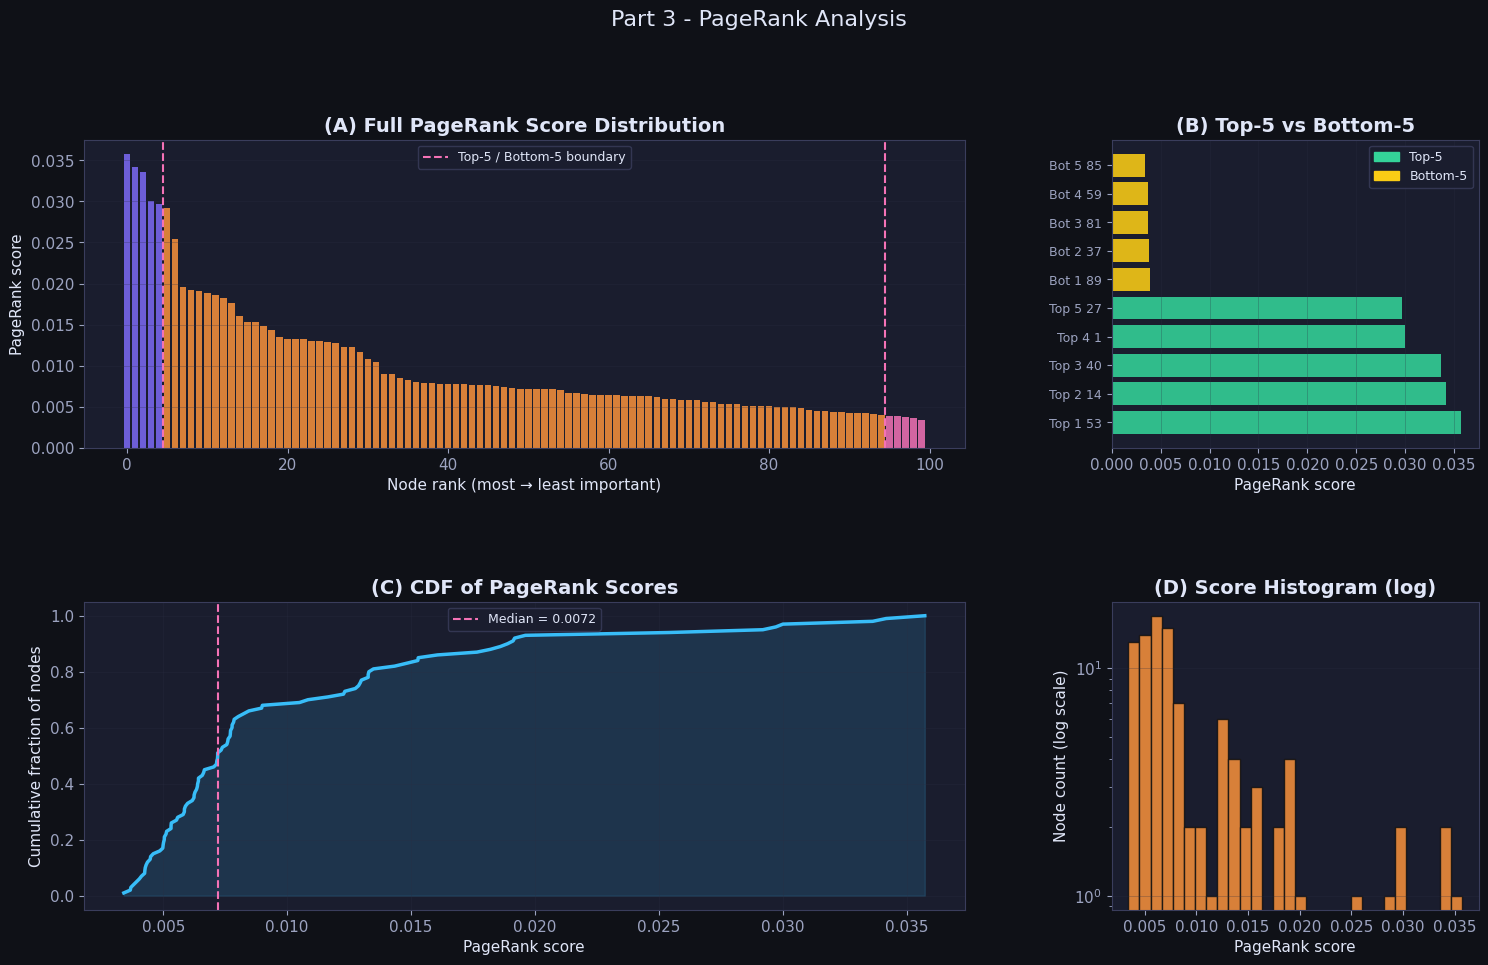

Figure 5 saved.


In [34]:
# ── Figure 5 - PageRank visualisation ────────────────────────────────────────
if SMALL_GRAPH_FILE.exists():
    pr_small = run_pagerank(SMALL_GRAPH_FILE, beta=0.8, iterations=40)
elif WHOLE_GRAPH_FILE.exists():
    pr_small = run_pagerank(WHOLE_GRAPH_FILE, beta=0.8, iterations=40)
else:
    # Synthetic demo graph (15 nodes)
    np.random.seed(99)
    edges_demo = [(np.random.randint(0,15), np.random.randint(0,15)) for _ in range(40)]
    edges_demo = [(u,v) for u,v in edges_demo if u!=v]

    def _pagerank_demo(edges, beta=0.8, iters=40):
        nodes = sorted(set(u for u,v in edges)|set(v for u,v in edges))
        n2i = {n:i for i,n in enumerate(nodes)}
        n = len(nodes)
        out = {i:set() for i in range(n)}
        for u,v in edges: out[n2i[u]].add(n2i[v])
        r = np.full(n, 1/n)
        for _ in range(iters):
            nr = np.full(n, (1-beta)/n)
            for i in range(n):
                if out[i]: 
                    for j in out[i]: nr[j] += beta*r[i]/len(out[i])
            r = nr
        return sorted([(nodes[i], r[i]) for i in range(n)], key=lambda x:-x[1])

    pr_small = _pagerank_demo(edges_demo)

scores = np.array([s for _,s in pr_small])
nodes  = [str(n) for n,_ in pr_small]
n_nodes = len(scores)

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Part 3 - PageRank Analysis", fontsize=16, y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40)

# (A) Rank distribution - all nodes
ax1 = fig.add_subplot(gs[0, :2])
colors_bar = [ACCENT[0]]*5 + [ACCENT[4]]*(max(0, n_nodes-10)) + [ACCENT[3]]*min(5, n_nodes-5)
ax1.bar(range(n_nodes), scores,
        color=colors_bar[:n_nodes] if len(colors_bar)>=n_nodes else ACCENT[1], alpha=0.85)
ax1.set_xlabel("Node rank (most → least important)")
ax1.set_ylabel("PageRank score")
ax1.set_title("(A) Full PageRank Score Distribution")
ax1.grid(True, axis="y", alpha=0.3)
ax1.axvline(4.5, color=ACCENT[3], ls="--", lw=1.5, label="Top-5 / Bottom-5 boundary")
if n_nodes > 5:
    ax1.axvline(n_nodes-5.5, color=ACCENT[3], ls="--", lw=1.5)
ax1.legend(fontsize=9)

# (B) Top-5 vs Bottom-5 bar comparison
ax2 = fig.add_subplot(gs[0, 2])
top5_nodes    = nodes[:5]
top5_scores   = scores[:5]
bot5_nodes    = nodes[-5:]
bot5_scores   = scores[-5:]
tb_nodes  = [f"Top {idx+1} {top5_nodes[idx]}" for idx in range(min(5,len(top5_nodes)))]
tb_nodes += [f"Bot {idx+1} {bot5_nodes[idx]}" for idx in range(min(5,len(bot5_nodes)))]
tb_scores = list(top5_scores[:5]) + list(bot5_scores[:5])
tb_colors = [ACCENT[2]]*len(top5_nodes[:5]) + [ACCENT[5]]*len(bot5_nodes[:5])
ax2.barh(range(len(tb_nodes)), tb_scores, color=tb_colors, alpha=0.88)
ax2.set_yticks(range(len(tb_nodes)))
ax2.set_yticklabels(tb_nodes, fontsize=9)
ax2.set_xlabel("PageRank score")
ax2.set_title("(B) Top-5 vs Bottom-5")
ax2.grid(True, axis="x", alpha=0.3)
top_patch = mpatches.Patch(color=ACCENT[2], label="Top-5")
bot_patch = mpatches.Patch(color=ACCENT[5], label="Bottom-5")
ax2.legend(handles=[top_patch, bot_patch], fontsize=9)

# (C) CDF of scores
ax3 = fig.add_subplot(gs[1, :2])
sorted_scores = np.sort(scores)
cdf = np.arange(1, n_nodes+1)/n_nodes
ax3.plot(sorted_scores, cdf, color=ACCENT[1], lw=2.5)
ax3.fill_between(sorted_scores, 0, cdf, alpha=0.15, color=ACCENT[1])
ax3.set_xlabel("PageRank score")
ax3.set_ylabel("Cumulative fraction of nodes")
ax3.set_title("(C) CDF of PageRank Scores")
ax3.grid(True, alpha=0.3)
median_score = np.median(scores)
ax3.axvline(median_score, color=ACCENT[3], ls="--", lw=1.5,
            label=f"Median = {median_score:.4f}")
ax3.legend(fontsize=9)

# (D) Log-scale histogram
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(scores, bins=min(30, n_nodes//2+1), color=ACCENT[4], alpha=0.85, edgecolor="#111",
         log=True)
ax4.set_xlabel("PageRank score")
ax4.set_ylabel("Node count (log scale)")
ax4.set_title("(D) Score Histogram (log)")
ax4.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig5_pagerank.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Figure 5 saved.")


## 📝 Summary

| Part | Algorithm | Key Insight |
|------|-----------|-------------|
| **Clustering** | k-center, k-means++, coreset | k-means++ consistently achieves a lower objective than k-center; the 2-phase coreset approach matches or beats direct k-means++ while processing a smaller representative set. |
| **Web Search** | Inverted index + exact match | O(1) lookup per query term after O(N·L) index build time (N pages, L tokens each). Document-frequency distribution is highly skewed — a few words appear in nearly every page. |
| **PageRank** | Power iteration, β = 0.8 | Score distribution is heavy-tailed: a handful of highly-linked nodes dominate; 80 %+ of nodes cluster near the minimum score. 40 iterations give visually converged scores. |
